In [1]:
import albumentations as A
import rasterio

In [2]:
from albumentations.pytorch.transforms import ToTensorV2

In [3]:
import os

In [4]:
import matplotlib.pyplot as plt

In [5]:
from skimage import exposure

In [6]:
import numpy as np

In [7]:
transform = A.Compose([
    A.CropNonEmptyMaskIfExists(height=256, width=256, ignore_values = [0]),
    #A.Resize(height=256, width=256),
    #A.CenterCrop (height=256, width=256),
    ToTensorV2()
])

In [8]:
os.chdir(r'D:\deep_learning\Sentinel_forestfire\MY_TEST_SENTINEL_IMAGERY_DATA\0525_512_temp')

In [9]:
with rasterio.open('imgs\\T52SCG_20200323T021559_2020005.tif') as src:
    image = src.read().transpose(1,2,0).astype('float32')
    

In [10]:
with rasterio.open('masks\\T52SCG_20200323T021559_2020005_mask.tif') as src:
    mask = src.read().transpose(1,2,0)
    

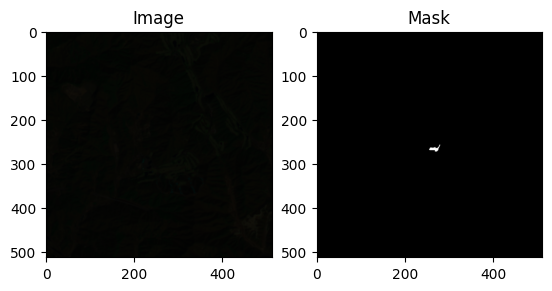

In [11]:
fig, ax = plt.subplots(1, 2)
ax[0].imshow(image[:,:,[5,3,1]]/65535)#, vmin=0, vmax = 1)
ax[0].set_title('Image')
ax[1].imshow(mask, cmap="gray", vmin=0, vmax = 1)
ax[1].set_title('Mask')
plt.show()

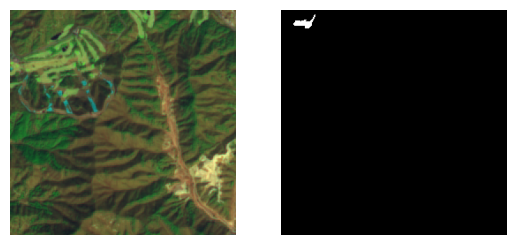

In [16]:
transformed = transform(image = image, mask = mask)
transformed_image = transformed['image']
transformed_mask = transformed['mask']
transformed_image = np.transpose(transformed_image, (1,2,0))
transformed_image2 = transformed_image[:,:,[5,3,1]]

transformed_image3 = transformed_image2.cpu().detach().numpy()
transformed_image_eq = exposure.adjust_gamma(transformed_image3)
#img = img / np.max(img) #normalize the image
transformed_image_eq2 = transformed_image_eq / np.max(transformed_image_eq) #normalize the image
fig, ax = plt.subplots(1, 2)
ax[0].imshow(transformed_image_eq2)#/65535, vmin=0, vmax = 1)
#ax[0].set_title('Image')
ax[1].imshow(transformed_mask, cmap="gray", vmin=0, vmax = 1)
#ax[1].set_title('Mask')
ax[0].axis('off')
ax[1].axis('off')
plt.show()

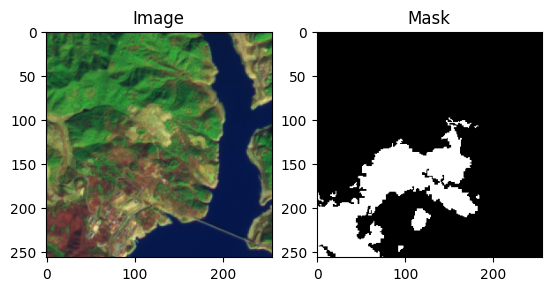